In [1]:
# Packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import zipfile
import matplotlib.pyplot as plt
# listing all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz


In [2]:
# Walk through the input directory to see the exact file paths
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        # Print first few files to understand the structure without overwhelming the output
        if files.index(file) < 3: 
            print(os.path.join(root, file))

/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz


In [3]:
# Load the binary NumPy archive
data = np.load('/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz')

# See what 'keys' (array names) are stored inside this file
print("Arrays available in this file:", data.files)

Arrays available in this file: ['data']


In [4]:
# 1. Open the file with mmap_mode='r' (read-only memory map)
# This lets us read the properties instantly without loading the 7.4 GB into RAM
data = np.load('/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz', mmap_mode='r')

# 2. Point to the array (this will now happen instantly)
stem_data = data['data']
# 3. Print the shape and type to see what we are dealing with
print("Data type:", stem_data.dtype)
print("Data shape:", stem_data.shape)

Data type: uint16
Data shape: (512, 512, 192, 192)


import numpy as np
import gc

#1. Force Python's garbage collector to clear out any lingering data chunks
gc.collect()

#2. Open file contextually so it automatically closes right away
file_path = '/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz'

with np.load(file_path, mmap_mode='r') as archive:
    # Safely extract structural metadata without loading the array data
    data_shape = archive['data'].shape
    data_type = archive['data'].dtype

print("--- SUCCESS ---")
print("Data shape:", data_shape)
print("Data type :", data_type)

In [5]:
file_path = '/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz'

# Open it as a standard zip archive instead of a NumPy file
with zipfile.ZipFile(file_path, 'r') as z:
    # Open the header of the internal 'data.npy' file without loading the matrix
    with z.open('data.npy') as f:
        version = np.lib.format.read_magic(f)
        shape, fort, dtype = np.lib.format.read_array_header_1_0(f)

print("--- BYPASSED RAM LOADING ---")
print("Data Shape:", shape)
print("Data Type :", dtype)

--- BYPASSED RAM LOADING ---
Data Shape: (512, 512, 192, 192)
Data Type : uint16


A data shape of (512, 512, 192, 192) means we are looking at a classic 4D-STEM data structure:

(512, 512) Real Space: The microscope scanned a grid of 512 by 512 pixels across the liquid cell containing your gold nanoparticles.
(192, 192) Reciprocal Space: At every single one of those 262,144 pixels, the microscope's camera captured a 192x192 electron diffraction pattern.

In [6]:
zip_path = '/kaggle/input/datasets/mdramjanali/prefiltered-4dstem-au-nanoparticle-liquid-cell-tem/Prefiltered_4DSTEM_Au_nanoparticle_liquid_cell_TEM.npz'
extract_dir = '/kaggle/working/'
extracted_npy_path = os.path.join(extract_dir, 'data.npy')

# Unzip only the data.npy file onto Kaggle's hard drive
if not os.path.exists(extracted_npy_path):
    print("Extracting data.npy to disk (this will take a moment)...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('data.npy', path=extract_dir)
    print("Extraction complete!")
else:
    print("File already extracted!")

Extracting data.npy to disk (this will take a moment)...
Extraction complete!


Reconstructing real-space image...


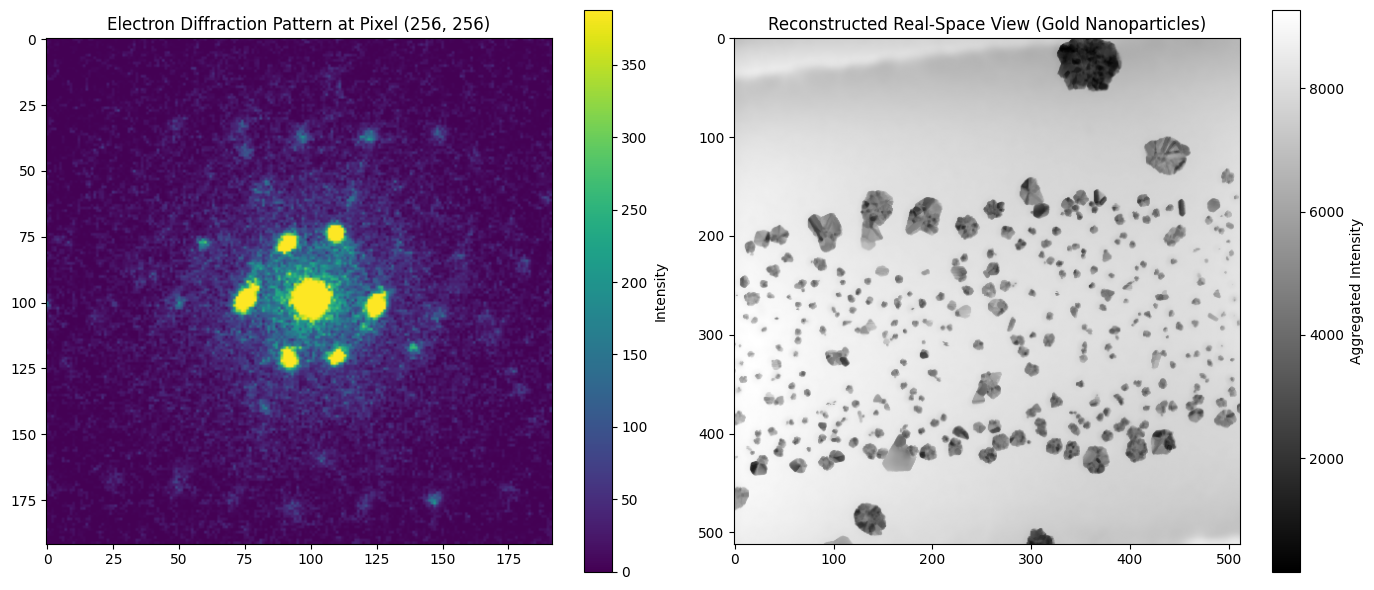

In [7]:
# Memory-map the uncompressed file directly from the hard drive
mmapped_data = np.load('/kaggle/working/data.npy', mmap_mode='r')

# Setup a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Plot 1: A single 2D Diffraction Pattern at spatial center (256, 256) ---
diff_pattern = mmapped_data[256, 256, :, :]
im1 = axes[0].imshow(diff_pattern, cmap='viridis', vmax=np.percentile(diff_pattern, 99))
axes[0].set_title("Electron Diffraction Pattern at Pixel (256, 256)")
fig.colorbar(im1, ax=axes[0], label='Intensity')

#Plot 2: Reconstruct a Real-Space Image (Virtual Bright Field) ---
# We sample a 10x10 patch at the center of the diffraction beam across the spatial grid
# This tricks the computer into rendering what the gold nanoparticles look like physically!
print("Reconstructing real-space image...")
virtual_image = np.mean(mmapped_data[:, :, 91:101, 91:101], axis=(2, 3))

im2 = axes[1].imshow(virtual_image, cmap='gray')
axes[1].set_title("Reconstructed Real-Space View (Gold Nanoparticles)")
fig.colorbar(im2, ax=axes[1], label='Aggregated Intensity')
plt.savefig('img.png')
plt.tight_layout()
plt.show()